<a href="https://colab.research.google.com/github/enriquefroes/treinadores-brasileirao-2026/blob/main/notebooks/01_aproveitamento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/analise_treinadores_brasileirao'
except ImportError:
    BASE = './analise_treinadores_brasileirao'

DADOS, GRAF, TAB = (os.path.join(BASE, p) for p in ['dados', 'graficos', 'tabelas'])
for p in (GRAF, TAB):
    os.makedirs(p, exist_ok=True)
if not os.path.exists(os.path.join(DADOS, 'jogos_por_treinador.csv')):
    raise FileNotFoundError('Rode primeiro o notebook 00_dados.ipynb')
jogos = pd.read_csv(os.path.join(DADOS, 'jogos_por_treinador.csv'), parse_dates=['data'])
folha = pd.read_csv(os.path.join(DADOS, 'folha.csv'))


K = 10
MIN_JOGOS = 5
JOGOS_TEMPORADA = 38

MEDIA_PPJ = jogos['pontos'].mean()

def resumo(df, chaves=('clube', 'treinador')):
    g = df.groupby(list(chaves))
    r = g.agg(jogos=('pontos', 'size'), pontos=('pontos', 'sum'),
              vitorias=('pontos', lambda s: (s == 3).sum()), empates=('pontos', lambda s: (s == 1).sum()),
              derrotas=('pontos', lambda s: (s == 0).sum()), gols_pro=('gols_pro', 'sum'), gols_contra=('gols_contra', 'sum'),
              primeiro_jogo=('data', 'min'), ultimo_jogo=('data', 'max'), tipo=('tipo', 'first')).reset_index()
    r['ppj'] = r['pontos'] / r['jogos']
    r['aproveitamento'] = r['ppj'] / 3 * 100
    r['primeiro_jogo'] = r['primeiro_jogo'].dt.date
    r['ultimo_jogo'] = r['ultimo_jogo'].dt.date
    return r

def rotulo(r):
    return f"{r['treinador']} ({r['clube']})" + (' · interino' if r['tipo'] == 'interino' else '')

def salvar(nome):
    plt.tight_layout()
    plt.savefig(os.path.join(GRAF, nome), dpi=150, bbox_inches='tight')
    plt.show()
    print('Salvo em', os.path.join(GRAF, nome))

Mounted at /content/drive


In [ ]:
r = resumo(jogos).sort_values('aproveitamento', ascending=False)
r['pontos_em_38'] = (r['ppj'] * JOGOS_TEMPORADA).round(0).astype(int)
tabela = r[['clube', 'treinador', 'tipo', 'jogos', 'vitorias', 'empates', 'derrotas', 'pontos', 'aproveitamento', 'pontos_em_38',
            'gols_pro', 'gols_contra', 'primeiro_jogo', 'ultimo_jogo']].round(1)
tabela.to_csv(os.path.join(TAB, '01_aproveitamento_bruto.csv'), index=False)
print(f'Média da liga: {MEDIA_PPJ:.2f} pontos por jogo ({MEDIA_PPJ/3*100:.1f}% de aproveitamento)')
tabela

Média da liga: 1.36 pontos por jogo (45.4% de aproveitamento)


,clube,treinador,tipo,jogos,vitorias,empates,derrotas,pontos,aproveitamento,pontos_em_38,gols_pro,gols_contra,primeiro_jogo,ultimo_jogo
34,São Paulo,Hernán Crespo,efetivo,4,3,1,0,10,83.3,95,6,2,2026-01-28,2026-02-25
20,Flamengo,Leonardo Jardim,efetivo,25,17,5,3,56,74.7,85,51,19,2026-03-11,2026-09-20
22,Fluminense,Marcão,efetivo,6,4,1,1,13,72.2,82,13,10,2026-08-15,2026-09-20
16,Cruzeiro,Artur Jorge,efetivo,20,13,2,5,41,68.3,78,34,24,2026-04-01,2026-09-20
27,Palmeiras,Abel Ferreira,efetivo,28,16,9,3,57,67.9,77,47,21,2026-01-28,2026-09-20
0,Athletico-PR,Odair Hellmann,efetivo,28,14,7,7,49,58.3,66,43,32,2026-01-28,2026-09-20
1,Atlético-MG,Eduardo Domínguez,efetivo,23,11,5,7,38,55.1,63,30,24,2026-03-11,2026-09-19
4,Bahia,Rogério Ceni,efetivo,28,12,10,6,46,54.8,62,43,35,2026-01-28,2026-09-20
31,Santos,Cuca,efetivo,20,9,5,6,32,53.3,61,31,27,2026-03-22,2026-09-19
21,Fluminense,Luis Zubeldía,efetivo,22,9,8,5,35,53.0,60,31,26,2026-01-28,2026-08-08


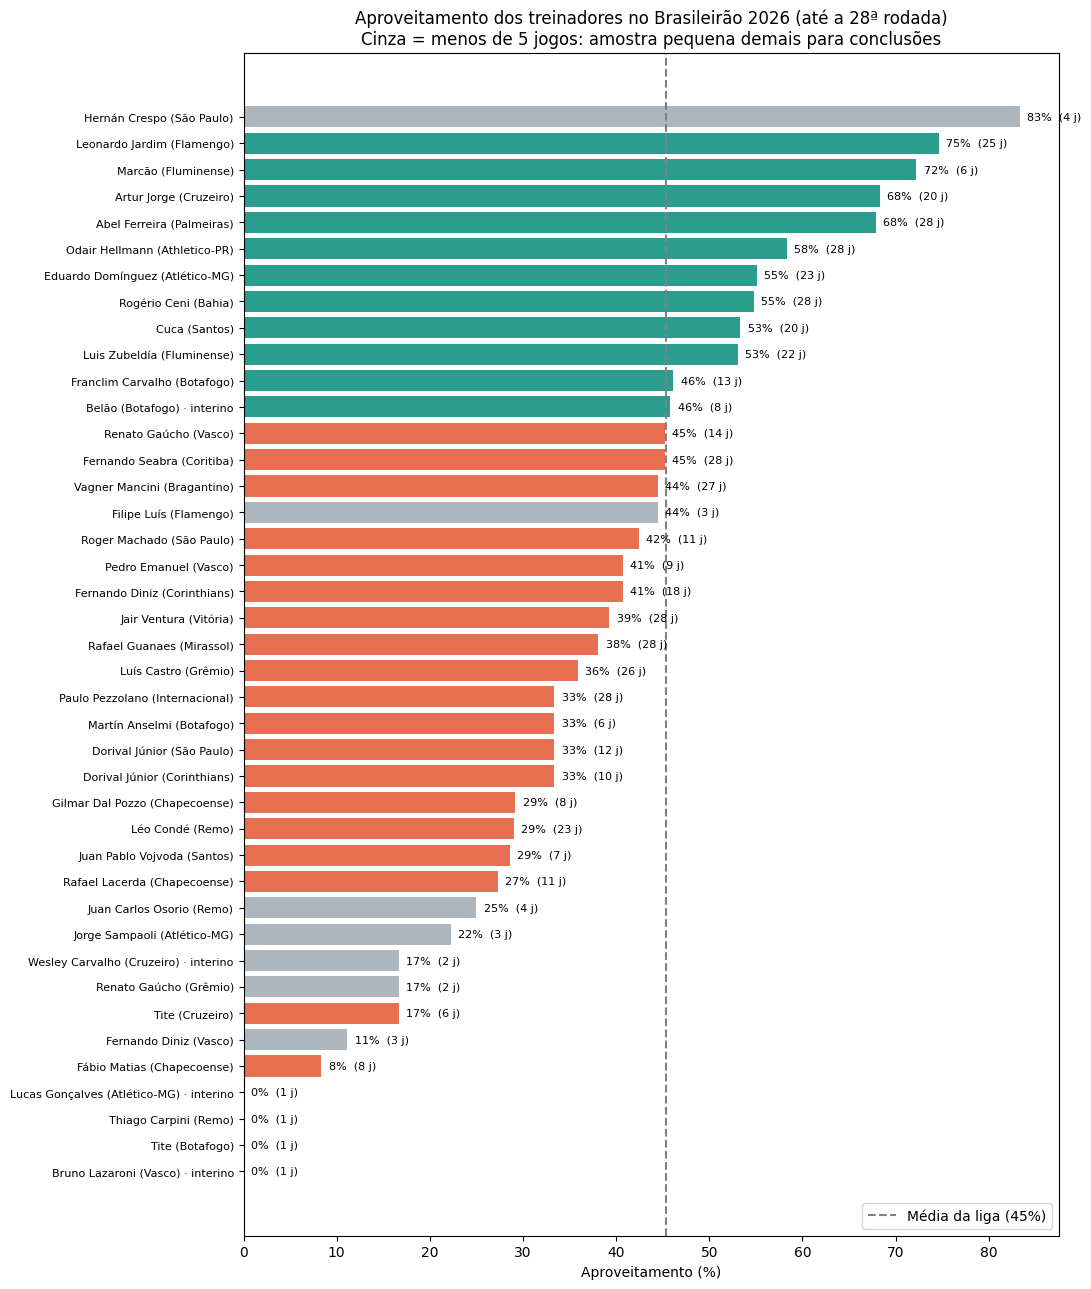

Salvo em /content/drive/MyDrive/analise_treinadores_brasileirao/graficos/01a_aproveitamento_bruto.png


In [ ]:
t = r.sort_values('aproveitamento')
fig, ax = plt.subplots(figsize=(11, 13))
cores = ['#adb5bd' if j < MIN_JOGOS else ('#2a9d8f' if a >= MEDIA_PPJ / 3 * 100 else '#e76f51') for j, a in zip(t['jogos'], t['aproveitamento'])]
ax.barh([rotulo(x) for _, x in t.iterrows()], t['aproveitamento'], color=cores)
for i, (a, j) in enumerate(zip(t['aproveitamento'], t['jogos'])):
    ax.text(a + 0.8, i, f'{a:.0f}%  ({j} j)', va='center', fontsize=8)
ax.axvline(MEDIA_PPJ / 3 * 100, ls='--', color='gray', label=f'Média da liga ({MEDIA_PPJ/3*100:.0f}%)')
ax.set_xlabel('Aproveitamento (%)')
ax.set_title(f'Aproveitamento dos treinadores no Brasileirão 2026 (até a 28ª rodada)\n'
             f'Cinza = menos de {MIN_JOGOS} jogos: amostra pequena demais para conclusões', fontsize=12)
ax.tick_params(axis='y', labelsize=8)
ax.legend(loc='lower right')
salvar('01a_aproveitamento_bruto.png')

In [ ]:
h = r[r['jogos'] >= MIN_JOGOS].sort_values('pontos_em_38', ascending=False).reset_index(drop=True)
h.index = h.index + 1
print('TABELA HIPOTÉTICA (aproveitamento bruto projetado para 38 jogos)')
print(h[['treinador', 'clube', 'jogos', 'aproveitamento', 'pontos_em_38']].round(1).to_string())
h[['treinador', 'clube', 'jogos', 'aproveitamento', 'pontos_em_38']].to_csv(os.path.join(TAB, '01_tabela_hipotetica_bruta.csv'))

TABELA HIPOTÉTICA (aproveitamento bruto projetado para 38 jogos)
             treinador          clube  jogos  aproveitamento  pontos_em_38
1      Leonardo Jardim       Flamengo     25            74.7            85
2               Marcão     Fluminense      6            72.2            82
3          Artur Jorge       Cruzeiro     20            68.3            78
4        Abel Ferreira      Palmeiras     28            67.9            77
5       Odair Hellmann   Athletico-PR     28            58.3            66
6    Eduardo Domínguez    Atlético-MG     23            55.1            63
7         Rogério Ceni          Bahia     28            54.8            62
8                 Cuca         Santos     20            53.3            61
9        Luis Zubeldía     Fluminense     22            53.0            60
10   Franclim Carvalho       Botafogo     13            46.2            53
11               Belão       Botafogo      8            45.8            52
12     Fernando Seabra       Coriti

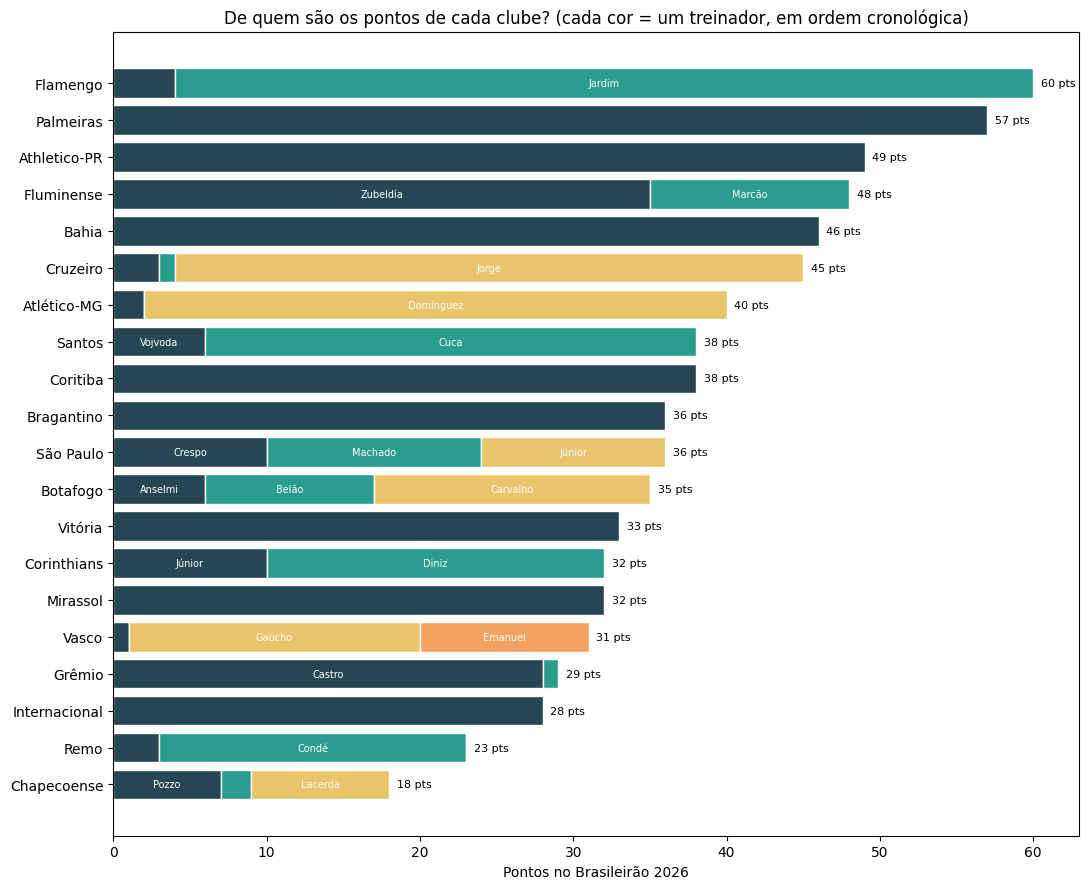

Salvo em /content/drive/MyDrive/analise_treinadores_brasileirao/graficos/01b_pontos_por_treinador_no_clube.png


In [ ]:
clubes = r.groupby('clube')['pontos'].sum().sort_values().index
fig, ax = plt.subplots(figsize=(11, 9))
paleta = ['#264653', '#2a9d8f', '#e9c46a', '#f4a261', '#e76f51']
for i, c in enumerate(clubes):
    sub = r[r['clube'] == c].sort_values('primeiro_jogo')
    esq = 0
    for k, (_, x) in enumerate(sub.iterrows()):
        ax.barh(i, x['pontos'], left=esq, color=paleta[k % len(paleta)], edgecolor='white')
        if x['pontos'] >= 5:
            ax.text(esq + x['pontos'] / 2, i, x['treinador'].split()[-1] if len(sub) > 1 else '', ha='center', va='center', fontsize=7, color='white')
        esq += x['pontos']
    ax.text(esq + 0.5, i, f'{esq} pts', va='center', fontsize=8)
ax.set_yticks(range(len(clubes)))
ax.set_yticklabels(clubes)
ax.set_xlabel('Pontos no Brasileirão 2026')
ax.set_title('De quem são os pontos de cada clube? (cada cor = um treinador, em ordem cronológica)', fontsize=12)
salvar('01b_pontos_por_treinador_no_clube.png')

In [ ]:
dois = r.groupby('treinador').filter(lambda g: g['clube'].nunique() > 1).sort_values(['treinador', 'primeiro_jogo'])
print(dois[['treinador', 'clube', 'jogos', 'pontos', 'aproveitamento', 'primeiro_jogo', 'ultimo_jogo']].round(1).to_string(index=False))

     treinador       clube  jogos  pontos  aproveitamento primeiro_jogo ultimo_jogo
Dorival Júnior Corinthians     10      10            33.3    2026-01-28  2026-04-05
Dorival Júnior   São Paulo     12      12            33.3    2026-05-16  2026-09-19
Fernando Diniz       Vasco      3       1            11.1    2026-01-29  2026-02-11
Fernando Diniz Corinthians     18      22            40.7    2026-04-12  2026-09-20
 Renato Gaúcho       Vasco     14      19            45.2    2026-03-12  2026-05-31
 Renato Gaúcho      Grêmio      2       1            16.7    2026-09-16  2026-09-20
          Tite    Cruzeiro      6       3            16.7    2026-01-29  2026-03-15
          Tite    Botafogo      1       0             0.0    2026-09-19  2026-09-19
